In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/rsna-bone-age")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kmader/rsna-bone-age


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
BASE_PATH = "/kaggle/input/datasets/kmader/rsna-bone-age"

IMAGE_DIR = f"{BASE_PATH}/boneage-training-dataset/boneage-training-dataset"

CSV_PATH = f"{BASE_PATH}/boneage-training-dataset.csv"

print("Dataset Files:")
print(os.listdir(BASE_PATH))

print("\nTotal Images:")
print(len(os.listdir(IMAGE_DIR)))

df = pd.read_csv(CSV_PATH)

print("\nCSV Shape:")
print(df.shape)

df.head()

Dataset Files:
['boneage-training-dataset.csv', 'boneage-training-dataset', 'boneage-test-dataset', 'boneage-test-dataset.csv']

Total Images:
12611

CSV Shape:
(12611, 3)


,id,boneage,male
0,1377,180,False
1,1378,12,False
2,1379,94,False
3,1380,120,True
4,1381,82,False


Sample Image:
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/9273.png

Original Shape:
(1794, 1290)


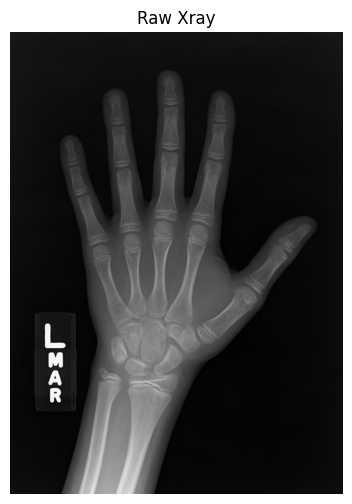

In [ ]:
sample_file = os.listdir(IMAGE_DIR)[0]

path = os.path.join(IMAGE_DIR, sample_file)

print("Sample Image:")
print(path)

img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

print("\nOriginal Shape:")
print(img.shape)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Raw Xray")
plt.axis("off")
plt.show()

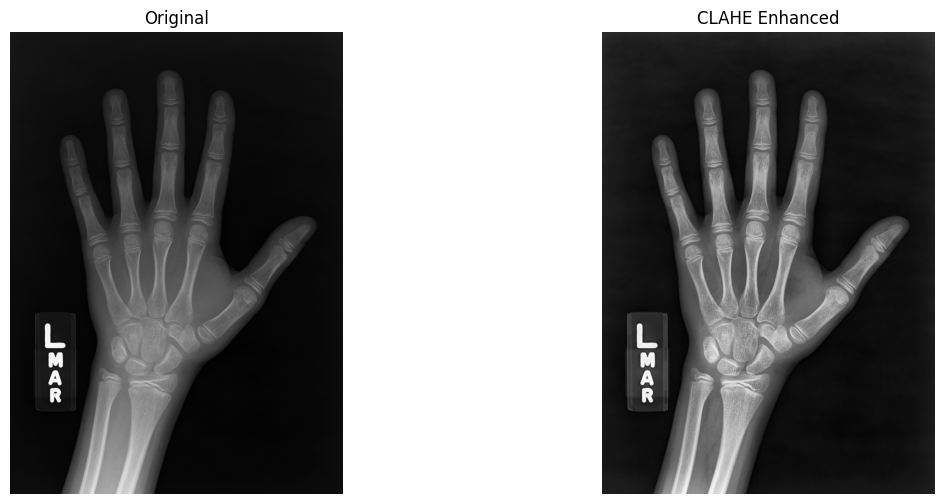

In [ ]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced = clahe.apply(img)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.show()

Crop Shape:
(1794, 1290)


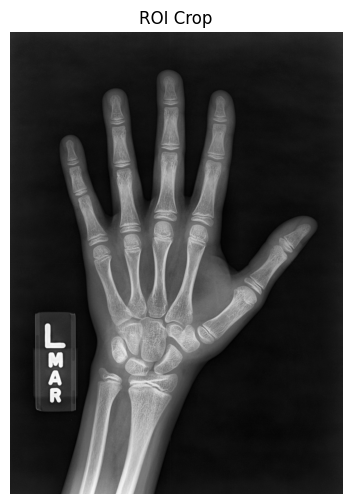

In [ ]:
# Binary threshold
_, thresh = cv2.threshold(
    enhanced,
    15,
    255,
    cv2.THRESH_BINARY
)

# Find contours
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Largest contour
largest = max(contours, key=cv2.contourArea)

# Bounding box
x, y, w, h = cv2.boundingRect(largest)

# Padding
pad = 40

x = max(0, x-pad)
y = max(0, y-pad)

crop = enhanced[
    y:y+h+pad,
    x:x+w+pad
]

print("Crop Shape:")
print(crop.shape)

plt.figure(figsize=(6,6))
plt.imshow(crop, cmap='gray')
plt.title("ROI Crop")
plt.axis("off")
plt.show()

Letterbox Shape:
(512, 512)


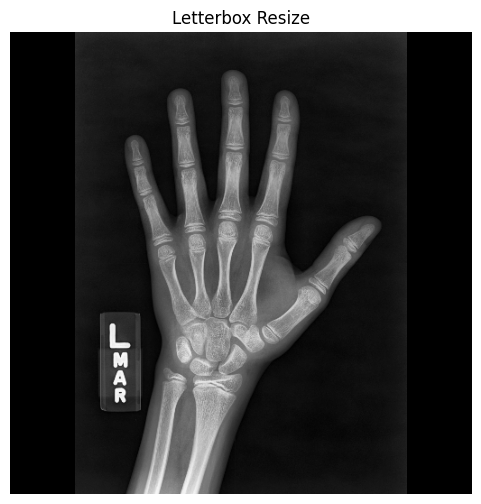

In [ ]:
target_size = 512

h, w = crop.shape

scale = min(target_size/w, target_size/h)

new_w = int(w * scale)
new_h = int(h * scale)

resized = cv2.resize(
    crop,
    (new_w, new_h)
)

canvas = np.zeros(
    (target_size, target_size),
    dtype=np.uint8
)

x_offset = (target_size - new_w) // 2
y_offset = (target_size - new_h) // 2

canvas[
    y_offset:y_offset+new_h,
    x_offset:x_offset+new_w
] = resized

print("Letterbox Shape:")
print(canvas.shape)

plt.figure(figsize=(6,6))
plt.imshow(canvas, cmap='gray')
plt.title("Letterbox Resize")
plt.axis("off")
plt.show()

In [ ]:
rgb = np.stack([canvas]*3, axis=-1)

print("RGB Shape:")
print(rgb.shape)

RGB Shape:
(512, 512, 3)


In [ ]:
files = os.listdir(IMAGE_DIR)[:10]

for file in files:

    try:

        path = os.path.join(IMAGE_DIR, file)

        processed = preprocess_image(path)

        print(file, "->", processed.shape)

    except Exception as e:

        print(file, "FAILED:", e)

9273.png -> (512, 512, 3)
14127.png -> (512, 512, 3)
9292.png -> (512, 512, 3)
11396.png -> (512, 512, 3)
14260.png -> (512, 512, 3)
4353.png -> (512, 512, 3)
7968.png -> (512, 512, 3)
6490.png -> (512, 512, 3)
5511.png -> (512, 512, 3)
6262.png -> (512, 512, 3)


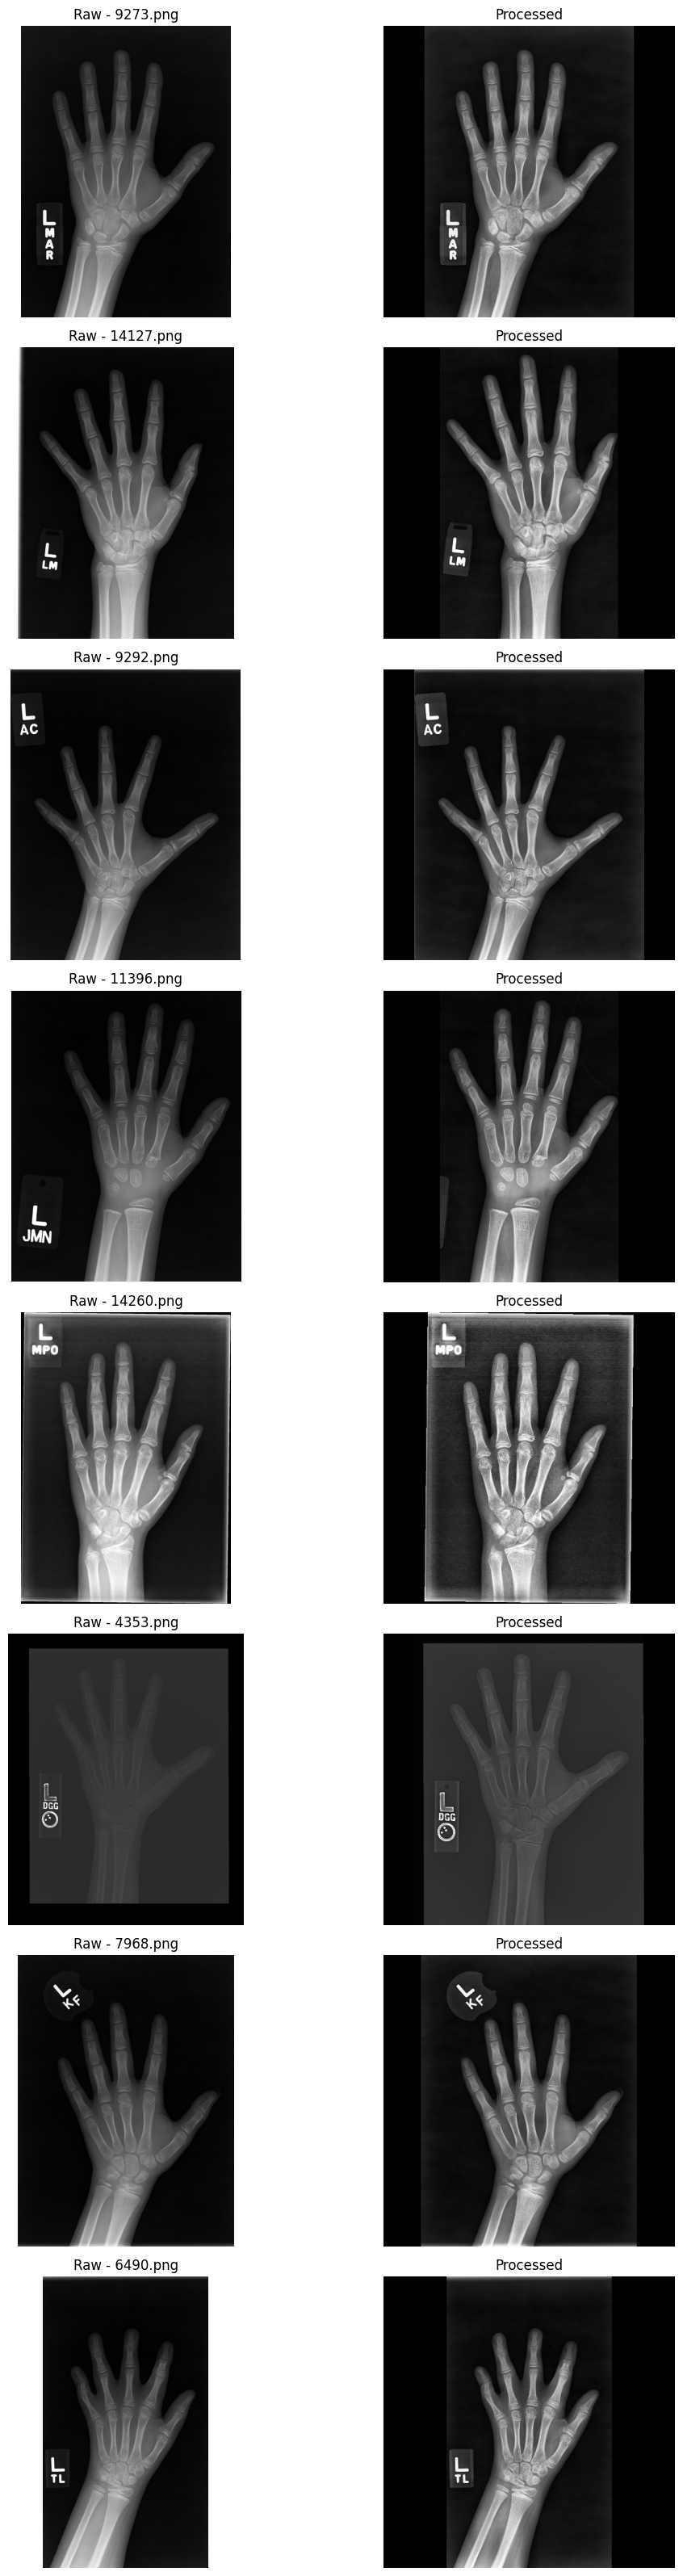

In [ ]:
files = os.listdir(IMAGE_DIR)[:8]

fig, axes = plt.subplots(8, 2, figsize=(12, 32))

for i, file in enumerate(files):

    path = os.path.join(IMAGE_DIR, file)

    # Raw image
    raw = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Processed image
    processed = preprocess_image(path)

    # Raw visualization
    axes[i, 0].imshow(raw, cmap='gray')
    axes[i, 0].set_title(f"Raw - {file}")
    axes[i, 0].axis("off")

    # Processed visualization
    axes[i, 1].imshow(processed[:, :, 0], cmap='gray')
    axes[i, 1].set_title("Processed")
    axes[i, 1].axis("off")

plt.tight_layout()

plt.show()